크롤링(Crawling)은 웹사이트의 HTML 문서나 API 데이터를 자동으로 수집하여 원하는 정보를 추출하는 기술입니다. 사람이 직접 웹페이지를 열어 뉴스, 상품 정보, 댓글, 주가, 날씨 등을 확인하는 과정을 프로그램이 대신 수행한다고 생각하면 이해하기 쉽습니다.

# 1. HTML
- 웹 브라우저에서 실행되는 웹페이지의 구조와 정보를 표현하기 위해 사용하는 표준 마크업 언어
- 문서의 제목, 이미지 링크, 입력창 등 다양한 콘텐츠의 의미와 구조를 정의
- 인터넷 상의 대부분의 웹페이지가 HTML을 기반으로 만들어진다.
- HTML 자체는 프로그래밍 언어처럼 복잡한 연산을 수행하기보다 웹 문서의 뼈대를 구성하는 역할을 한다
- CSS는 화면의 디자인을 담당하고 JavaScript는 동적인 기능을 구현한다.
- 웹 크롤링에서는 사이트의 데이터가 HTML 구조 안에 저장되어 있기 때문에, 원하는 정보를 수집하고 분석하기 위해 반드시 이해해야 하는 핵심 기술로 사용됨.
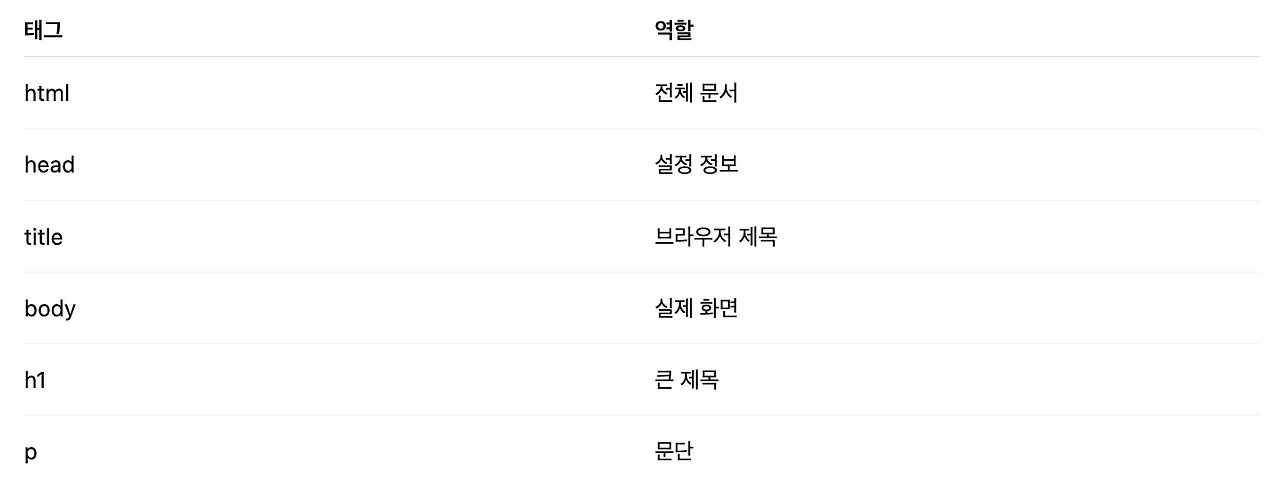


### Requests
- Python에서 웹 서버에 HTTP 요청을 보내고 응답을 받아오기 위해 사용하는 대표적인 라이브러리
- 웹 브라우저가 사이트에 접속할 때처럼 Python 코드에서도 웹페이지, 이미지, JSON 데이터 등을 서버로부터 가져올 수 있게 해주며, 
- 웹 크롤링과 API 연동에서 가장 많이 사용되는 기본 도구
- request.get()으로 웹페이지를 요청
- requests.post()로 데이터를 서버에 전송할 수 있음
- 응답 결과로 HTML코드, 이미지 데이터, 상태 코드 등을 쉽게 다룰 수 있다.
```
python -m pip install requests
```

### Beautiful Soup
- from bs4 import BeautifulSoup 코드는 Python에서 HTML이나 XML 문서를 쉽게 분석하고 원하는 데이트를 추출하기 위해 BeautifulSoup 클래스를 불러오는 코드
- bs4는 BeautifulSoup4 라이브러리를 의미
- 웹 크롤링에서 가장 많이 사용하는 라이브러리 중 하나
```
# 설치
python -m pip install bs4
```


### 1. \<h1\> & \<p\>

In [1]:
import requests
from bs4 import BeautifulSoup

In [2]:
# 가상 서버 주소
url = "http://127.0.0.1:5500/1.html"

# 서버에 요청 보내기
response = requests.get(url)

# HTML 코드 가져오기
html = response.text

# HTML 분석
soup = BeautifulSoup(html, "html.parser")  # html 분석시에 html.parser, xml 분석시 xml.parser 사용.

# 데이터 추출
h1 = soup.find("h1").text
p = soup.find("p").text

# 출력
print('Title:', h1)
print('Detail:', p)


Title: Hello
Detail: Python Crawling


>- find()는 Beautiful Soup에서 HTML 문서 안의 특정 태그를 검색할 때 사용하는 함수
>- 태그 이름, 클래스(class), 아이디(id) 등의 조건을 기준으로 원하는 요소를 찾을 수 있음
>- 조건에 맞는 첫 번째 요소만 반환
>- 예: find("h1")은 첫 번째 \<h1\> 태그를 가져오고, .text를 사용하면 태그 안의 글자만 추출할 수 있다.

### 2. \<div\>
```<!doctype html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0" />
    <title>뉴스</title>
  </head>
  <body>
    <div>
      <h1>뉴스 제목</h1>
      <p>뉴스 내용</p>
    </div>
  </body>
</html>
```

>-  \<div\> 태그는 HTML에서 여러 요소를 하나의 영역으로 묶어주는 컨테이너(Container) 역할을 한다.
>- 위 코드에서는 \<div\>가 부모 노드가 되고, 그 안에 \<h1\>과 \<p\> 태그가 자식 노드 형태로 포함되어 트리 구조를 형성한다.
>- 뉴스 제목과 뉴스 내용을 하나의 그룹으로 묶어 관리하는 역할을 함.
>- 웹페이지를 구조적으로 구분할 때 매우 자주 사용됨.
>- 웹 크롤링에서도 특정 \<div\> 내부의 데이터를 찾는 방식으로 원하는 정보를 추출하는 경우가 많다.

In [3]:
# 가상 서버 주소
url = "http://127.0.0.1:5500/2.html"

# 서버에 요청 보내기
response = requests.get(url)

# HTML 가져오기
html = response.text

# HTML 분석
soup = BeautifulSoup(html, "html.parser")

# 부모 태그(div) 가져오기
div = soup.find("div")

# 자식 태그 가져오기
news_title = div.find("h1").text
news_content = div.find("p").text

# 출력
print("News Title:", news_title)
print("News Content:", news_content)

News Title: News Title
News Content: News Content


### 3. Hyperlink
```
<!doctype html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0" />
    <title>Hyperlink</title>
  </head>
  <body>
    <a href="https://naver.com">Naver</a>
    <a href="https://google.com">Google</a>
  </body>
</html>
```

>- \<a\> 태그는 다른 웹페이지나 사이트로 이동할 수 있는 Hyperlink를 만드는 태그 이다.
>- href 속성에는 이동할 주소(URL)를 작성하며, 태그 사이의 글자는 실제 화면에서 클릭 가능한 링크 텍스트로 표시된다.
>- 웹 크롤링에서는 \<a\> 태그의 href 값을 수집하여 게시글 주소, 상품 링크, 뉴스 URL 등을 추출하는 데 매우 자주 활용된다.

In [4]:
# 가상 서버 주소
url = "http://127.0.0.1:5500/3.html"

# 서버 요청
response = requests.get(url)

# HTML 가져오기
html = response.text

# HTML 분석
soup = BeautifulSoup(html, "html.parser")

# 모든 a(Anchor) 태그 가져오기
links = soup.find_all("a")

# 링크와 글자 출력
for link in links:
  text = link.text  # Naver, Google
  href = link["href"]  # 대괄호 안에는 속성이 들어감.

  print("Website Name:", text)
  print("Link Address:", href)
  print()


Website Name: Naver
Link Address: https://naver.com

Website Name: Google
Link Address: https://google.com



### 4. Image
```
<!doctype html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0" />
    <title>이미지</title>
  </head>
  <body>
    <img src="./images/example.jpeg" />
  </body>
</html>
```

>- \<img\> 태그는 웹페이지에 이미지를 출력할 때 사용하는 태그
>- src 속성에는 불로올 이미지 파일의 경로 또는 주소를 작성
>- \<img\> 태그는 종료 태그 없이 사용하는 대표적인 단일 태그
>- 웹사이트의 사진, 상품 이미지, 프로필 이미지 등을 출력할 때 매우 많이 사용됨.
>- 웹 크롤링에서는 \<img\> 대그의 src 값을 수집하여 이미지 주소를 추출하거나 이미지를 다운로드하는 방식으로 활용된다.

In [5]:
import os
from urllib.parse import urljoin

In [6]:
# HTML 페이지 요청
url = "http://127.0.0.1:5500/4.html"

response = requests.get(url)

# HTML 파싱
soup = BeautifulSoup(response.text, "html.parser")

# img 태그 찾기
img_tag = soup.find("img")

# 이미지 주소 가져오기
img_src = img_tag["src"]

# 상대경로 → 절대경로 변환
img_url = urljoin(url, img_src)

print("이미지 주소:", img_url)

# images 폴더 생성
os.makedirs("downloads", exist_ok=True)

# 이미지 다운로드
img_response = requests.get(img_url)

# 파일 이름 추출
# "./images/example.jpeg"
# [".", "images", "example.jpeg"]
file_name = img_src.split("/")[-1]

# 저장 경로
save_path = os.path.join("downloads", file_name)

# 이미지 저장
with open(save_path, "wb") as file:
  file.write(img_response.content)

print("image saved")

이미지 주소: http://127.0.0.1:5500/images/example.jpeg
image saved


### open() 함수
- 파일을 읽거나 저장할 때 사용하는 함수
- 텍스트 파일(txt), CSV, 이미지 파일 등을 열어서 데이터를 읽거나 저장할 수 있다.
- 크롤링, 데이터분석, AI 개발 등 거의 모든 분야에서 사용되는 매우 중요한 기능
```
파일객체 = open("파일명", "모드", encoding="utf-8")
```
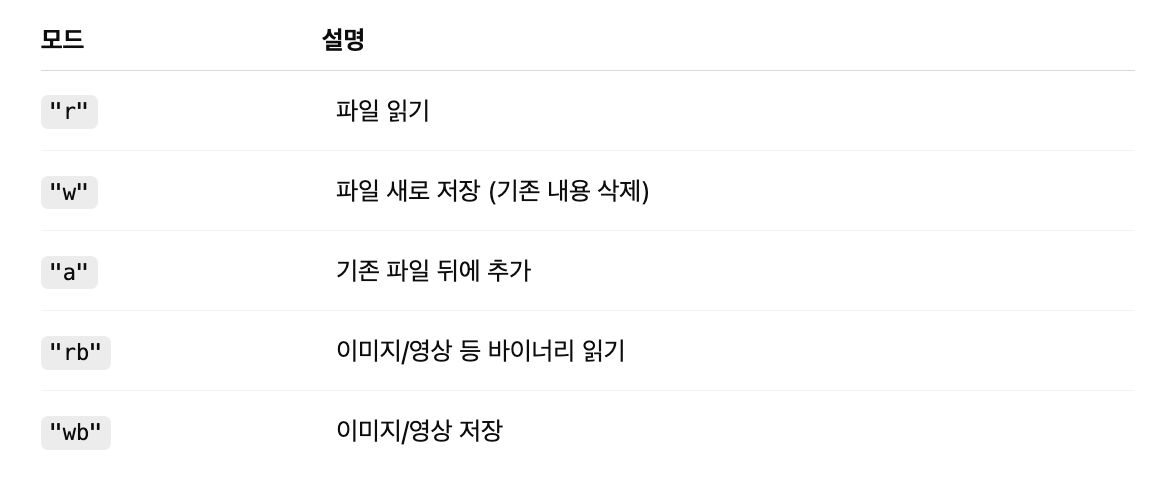

### 5. Table
```
<!doctype html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0" />
    <title>표</title>
  </head>
  <body>
    <table border="1">
      <tr>
        <th>이름</th>
        <th>나이</th>
      </tr>
      <tr>
        <td>김사과</td>
        <td>20</td>
      </tr>
    </table>
  </body>
</html>
```

>- \<table\> 태그는 데이터를 행(Row)과 열(Column) 형태로 정리하여 표(Table)를 만드는 태그
>- 학생 정보, 상품 목록, 통계 데이터 등을 표현할 때 자주 사용된다.
>- 웹 크롤링에서는 \<table\> 내부의 행과 열을 반복적으로 탐색하여 데이터를 수집하는 방식으로 많이 활용된다.

In [7]:
# 가상 서버 주소
url = "http://127.0.0.1:5500/5.html"

# 서버 요청
response = requests.get(url)

# HTML 가져오기
html = response.text

# HTML 분석
soup = BeautifulSoup(html, "html.parser")

# table 가져오기
table = soup.find("table")

# 제목(th: table header) 추출
headers = table.find_all("th")

print("<Title>")
for header in headers:
  print(header.text)

# 내용(td: table data) 추출
datas = table.find_all("td")

print("\n<Data>")
for data in datas:
  print(data.text)


<Title>
Name
Age

<Data>
Lucas
20


---
# 2. CSS
- HTML로 만들어진 웹페이지의 색상, 크기, 배치, 글꼴, 애니메이션 등 화면의 디자인과 스타일을 담당하는 스타일 시트 언어
- HTML이 웹페이지의 구조와 내용을 정의
- CSS는 그 요소들을 어떻게 보이게 할지를 결정하는 역할
- 글자 색상 변경, 이미지 크기 조절, 화면을 반응형으로 배치하는 작업 등을 처리
- 클래스(class)와 아이디(id)를 이용해 특정 요소에만 스타일을 적용할 수 있다.
- 웹사이트를 더 보기 좋고 사용자 친화적으로 만드는 핵심 기술 

```
/* style1.css */

#title {
  font-size: 30px;
  color: blue;
  font-weight: bold;
}

.item {
  border: 1px solid gray;
  padding: 10px;
  margin: 10px;
}
```

```
<!doctype html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0" />
    <title>쇼핑몰</title>
    <link rel="stylesheet" href="style1.css" />
  </head>
  <body>
    <div id="title">IT</div>
    <div class="item">
      <h2>노트북</h2>
      <p>150만원</p>
    </div>

    <div class="item">
      <h2>키보드</h2>
      <p>10만원</p>
    </div>
  </body>
</html>
```

>- id와 class는 HTML 요소를 구분하고 선택하기 위해 사용하는 속성
>- id는 하나의 요소에만 부여하는 고유한 이름. 보통 페이지 안에서 단 하나만 존재해야 하며, 특정 영역을 정확하게 선택할 때 사용
>- class는 여러 요소에 공통으로 부여할 수 있는 이름. 같은 디자인이나 기능을 여러 곳에 반복 적용할 때 사용한다.
>- CSS에서는 id를 #이름 형태로 선택하고, class는 .이름 형태로 선택하여 스타일을 적용한다.


In [8]:
# 가상 서버 주소
url = "http://127.0.0.1:5500/6.html"

# 서버 요청
response = requests.get(url)

# HTML 가져오기
html = response.text

# HTML 분석
soup = BeautifulSoup(html, "html.parser")

# id 선택자
title = soup.select_one("#title").text

print("Category:", title)

# class 선택자
items = soup.select(".item")

for item in items:
  name = item.select_one("h2").text
  price = item.select_one("p").text

  print("Item:", name)
  print("Price:", price)
  print()

Category: IT
Item: Laptop
Price: $1,500

Item: Keyboard
Price: $100



>- select()는 BeautifulSoup에서 CSS 선택자(CSS Selector) 문법을 사용하여 원하는 HTML 요소들을 여러 개 선택할 때 사용하는 함수
>- 태그명(h1), 클래스(.item), 아이디(#title) 등을 조합하여 원하는 요소를 탐색할 수 있음
>- 조건에 맞는 모든 요소를 리스트 형태로 반환
>- soup.select(".item")은 class="item"인 모든 요소를 가져오며, 반복문과 함께 사용하여 상품 목록, 뉴스 리스트, 게시글 목록 등을 한 번에 크롤링할 때 많이 사용
>- select_one()이 첫 번째 요소 하나만 가져온다면, select()는 여러 개의 요소를 모두 가져온다.

---
# 3. 활용
### 1. basicenglishspeaking 75개 topic 크롤링

In [9]:
import pandas as pd

In [11]:
site = 'https://basicenglishspeaking.com/daily-english-conversation-topics/'

request = requests.get(site)
request

<Response [200]>

In [13]:
soup = BeautifulSoup(request.text, 'html.parser')

div = soup.find('div', {'class': 'thrv-columns'})
div

<div class="thrv_wrapper thrv-columns" style="--tcb-col-el-width:792"><div class="tcb-flex-row tcb--cols--3"><div class="tcb-flex-col"><div class="tcb-col"><div class="thrv_wrapper thrv_text_element"><p>1. <a class="tve-froala" href="https://basicenglishspeaking.com/family/" style="outline:none">Family</a><br/>2. <a class="tve-froala" href="https://basicenglishspeaking.com/restaurant/" style="outline:none">Restaurant</a><br/>3. <a href="https://basicenglishspeaking.com/books/">Books</a><br/>4. <a href="https://basicenglishspeaking.com/travel/">Travel</a><br/>5. <a href="https://basicenglishspeaking.com/website/">Website</a><br/>6. <a href="https://basicenglishspeaking.com/accident/">Accident</a><br/>7. <a class="tve-froala" href="https://basicenglishspeaking.com/childhood-memory/" style="outline:none">Childhood memory</a><br/>8. <a class="tve-froala" href="https://basicenglishspeaking.com/favorite-rooms/" style="outline:none">Favorite rooms</a><br/>9. <a href="https://basicenglishspeak

In [15]:
links = div.find_all('a')
links

[<a class="tve-froala" href="https://basicenglishspeaking.com/family/" style="outline:none">Family</a>,
 <a class="tve-froala" href="https://basicenglishspeaking.com/restaurant/" style="outline:none">Restaurant</a>,
 <a href="https://basicenglishspeaking.com/books/">Books</a>,
 <a href="https://basicenglishspeaking.com/travel/">Travel</a>,
 <a href="https://basicenglishspeaking.com/website/">Website</a>,
 <a href="https://basicenglishspeaking.com/accident/">Accident</a>,
 <a class="tve-froala" href="https://basicenglishspeaking.com/childhood-memory/" style="outline:none">Childhood memory</a>,
 <a class="tve-froala" href="https://basicenglishspeaking.com/favorite-rooms/" style="outline:none">Favorite rooms</a>,
 <a href="https://basicenglishspeaking.com/presents/">Presents</a>,
 <a class="tve-froala" href="https://basicenglishspeaking.com/historical-place/" style="outline:none">Historical place</a>,
 <a class="tve-froala" href="https://basicenglishspeaking.com/newspaper-magazine/" style

In [23]:
data = []

for i, link in enumerate(links, start=1):
  topic = link.text.strip()
  url = link.get('href')

  data.append({
    'number': i,
    'topic': topic,
    'link': url
  })

df = pd.DataFrame(data)
df.set_index('number', inplace=True)
df

,topic,link
number,,
1,Family,https://basicenglishspeaking.com/family/
2,Restaurant,https://basicenglishspeaking.com/restaurant/
3,Books,https://basicenglishspeaking.com/books/
4,Travel,https://basicenglishspeaking.com/travel/
5,Website,https://basicenglishspeaking.com/website/
...,...,...
71,Technological advancements,https://basicenglishspeaking.com/technological...
72,A Landmark,https://basicenglishspeaking.com/a-landmark/
73,Handcraft Items,https://basicenglishspeaking.com/handcraft-items/


### 2. 다음 뉴스기사 크롤링

In [40]:
def daum_news(news_id):
  url = f'https://v.daum.net/v/{news_id}'

  headers = {
    'User-Agent': 'Mozilla/5.0'
  }

  try:
    request = requests.get(url, headers = headers)
    # print(request)

    # 요청 실패 시 에러 발생
    request.raise_for_status()

    soup = BeautifulSoup(request.text, 'html.parser')

    # 제목 가져오기
    title = soup.find('h3', {'class': 'tit_view'})

    if title:
      title = title.text.strip()
    else:
      title = 'No Title'

    # print(title)

    # 본문 가져오기
    content = soup.find('div', {'class': 'article_view'})

    if content:
      content = content.text.strip()
    else:
      content = 'No Content'

    return {
      'title': title,
      'content': content
    }

  except Exception as e:
    print('error occured:', e)
    return None
  


In [41]:
news = daum_news('20260608171656309')

print('제목:')
print(news['title'])

print('\n본문:')
print(news['content'])

제목:
하이닉스 8% 떨어졌는데…ACE단일종목 레버리지 50%↑'이상거래'(종합)

본문:
한국투자증권·한국투자신탁운용 [연합뉴스TV 제공]
           

(서울=연합뉴스) 고은지 기자 = 8일 SK하이닉스 주가가 8% 가까이 떨어졌는데도 'ACE SK하이닉스단일종목레버리지'는 50%가량 급등하는 기현상이 나타났다.
한국거래소에 따르면 한국투자신탁운용의 'ACE SK하이닉스단일종목레버리지'는 이날 전장보다 49.70% 오른 3만원에 거래를 마쳤다.
해당 종목의 주가는 장중 내내 하락세를 이어가다가 장 막판 갑자기 50% 가까이 튀어 올랐다.
SK하이닉스단일종목레버리지는 SK하이닉스의 주가 수익률을 2배로 추종하는 상품이다. 
이날 SK하이닉스는 7.68% 내린 191만1천원에 거래를 마감했다.
이에 따라 SK하이닉스 단일종목레버리지는 그 두배인 15∼16%가량 하락하는 것이 정상적인 상황이다.
실제로 해당 상품을 제외한 SK하이닉스 단일종목레버리지 6개는 모두 15∼18%가량 하락했다.
이번 이상거래는 유동성공급자(LP)의 호가 제출 의무가 없는 장 마감 직전에 호가가 벌어졌고, 호가가 튄 상황에서 시장가로 매수 주문을 체결한 투자자들의 주문이 체결돼 벌어진 것으로 파악됐다.
ETF는 LP의 호가 제출을 통해 순자산가치와의 괴리율이 벌어지는 것을 막는다. 다만, 오후 3시 20∼30분 동시호가 시간에는 LP의 호가 제출 의무가 면제된다.
이때 거래량이 적고 호가창이 얇은 상품의 경우 누군가가 비정상적인 가격으로 주문을 내면 가격이 크게 왜곡되는 일이 일어날 수 있다.
한투운용은 "이번 일을 계기로 LP 호가 체계를 점검하고, 추가적인 문제가 발생하지 않도록 주의를 다하겠다"고 말했다.
문제는 해당 시간 3만원에 해당 상품을 매수한 투자자다.
다음날 개장하면서 LP가 다시 유동성 공급에 나서면 주가가 본래 가격으로 되돌아가게 되기 때문이다.
다른 SK하이닉스 단일종목 레버리지 수준인 1만6천원 선으로 내려간다면 3만원에 매수한 투자자들은 50% 안팎의 

>- headers는 웹 브라우저가 서버에 보내는 추가 정보
>- 클롤링에서는 서버가 요청을 정상적인 브라우저 접속으로 인식하도록 도와주는 역할
>- User-Agent는 "어떤 브라우저와 운영체제로 접속했는가"를 나타내는 정보로, 이를 설정하지 않으면 일부 사이트는 프로그램(봇) 접속으로 판단하여 데이터를 차단하거나 빈 페이지를 반환할 수 있음
>- Referer는 "어떤 페이지에서 이동해 왔는가"를 나타내는 정보이며, 벅스 같은 사이트는 내부 페이지 이동처럼 보여야 정상 응답을 주는 경우가 있어 함께 설정하는 경우가 많음.
>- headers는 크롤링 프로그램이 실제 사람이 사용하는 브라우저처럼 보이게 만들어 사이트 차단을 출이고 안정적으로 데이터를 가져오기 위해 사용하는 설정.

### robots.txt
- 웹사이트 운영자가 검색 엔진이나 크롤링 프로그램(봇)에게 "접근 가능/불가능한 페이지"를 알려주는 규칙 파일
- 사이트 주소 뒤에 /robots.txt를 붙여 확인할 수 있음 (https://example.com/robots.txt) 형태
- 특정 경로를 수집 금지 (Disallow) 하거나 허용(Allow) 하는 규칙이 작성되어있음.

### 3. 벅스 아티스트 곡 리스트 크롤링

In [51]:

def bugs_artist_tracks(artist_id):
    url = f"https://music.bugs.co.kr/artist/{artist_id}/tracks"

    headers = {
        "User-Agent": "Mozilla/5.0",
        "Referer": "https://music.bugs.co.kr/"
    }

    response = requests.get(url, headers=headers)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    rows = soup.select("table.list.trackList tbody tr")
    # print(rows)
    
    data = []

    for row in rows:
        title_tag = row.select_one("p.title a")
        artist_tag = row.select_one("p.artist a")
        album_tag = row.select_one("a.album")

        if not title_tag:
            continue
        
        title = title_tag.get_text(strip=True) 
        artist = artist_tag.get_text(strip=True) if artist_tag else ""
        album = album_tag.get_text(strip=True) if album_tag else ""

        # print(title)
        # print(artist)
        # print(album)
        # print('----------')

        data.append({
            "Title": title,
            "Artist": artist,
            "Album": album
        })

    df = pd.DataFrame(data)
    df.index = df.index + 1

    file_name = f"bugs_artist_{artist_id}_tracks.csv"
    df.to_csv(file_name, encoding="utf-8-sig")

    return df

In [52]:
df = bugs_artist_tracks("20260859")
df

,Title,Artist,Album
1,이젠 내가 더 사랑해 (PJ2),신의키스,The Bucket List
2,너 없는 생일,신의키스,The Bucket List
3,서로를 가장 잘 아는 남,신의키스,The Bucket List
4,헤어질 준비,신의키스,The Bucket List
5,이젠 내가 더 사랑해 (PJ1),신의키스,The Bucket List
6,버킷 리스트,신의키스,The Bucket List


In [53]:
import time

In [57]:
def bugs_artist_tracks_all_pages(artist_id, max_page=20):
    headers = {
        "User-Agent": "Mozilla/5.0",
        "Referer": "https://music.bugs.co.kr/"
    }

    all_data = []

    for page in range(1, max_page + 1):
        url = (
            f"https://music.bugs.co.kr/artist/{artist_id}/tracks"
            f"?type=RELEASE&sort=P&page={page}&roleCode=0&highQualityOnly="
        )

        response = requests.get(url, headers=headers)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, "html.parser")

        rows = soup.select("table.trackList tbody tr")

        page_data = []

        for row in rows:
            title_tag = row.select_one("p.title a")
            artist_tag = row.select_one("p.artist a")
            album_tag = row.select_one("a.album")

            if title_tag is None:
                continue

            page_data.append({
                "곡명": title_tag.get_text(strip=True),
                "아티스트": artist_tag.get_text(strip=True) if artist_tag else "",
                "앨범명": album_tag.get_text(strip=True) if album_tag else "",
                "페이지": page
            })

        if len(page_data) == 0:
            print(f"{page}페이지에 곡이 없어 종료합니다.")
            break

        all_data.extend(page_data)
        print(f"{page}페이지 크롤링 완료: {len(page_data)}곡")

        time.sleep(0.5)

    df = pd.DataFrame(all_data)

    if not df.empty:
        df = df.drop_duplicates(subset=["곡명", "아티스트", "앨범명"])
        df.index = df.index + 1

    file_name = f"bugs_artist_{artist_id}_tracks.csv"
    df.to_csv(file_name, encoding="utf-8-sig")

    print(f"CSV 저장 완료: {file_name}")
    print(f"총 {len(df)}곡 수집 완료")

    return df

In [58]:
df = bugs_artist_tracks_all_pages('80021125')
df

1페이지 크롤링 완료: 50곡
2페이지 크롤링 완료: 50곡
3페이지 크롤링 완료: 35곡
4페이지에 곡이 없어 종료합니다.
CSV 저장 완료: bugs_artist_80021125_tracks.csv
총 135곡 수집 완료


,곡명,아티스트,앨범명,페이지
1,"봄날, 벚꽃 그리고 너",에피톤 프로젝트(Epitone Project),긴 여행의 시작,1
2,나는 그 사람이 아프다 (feat. 타루),에피톤 프로젝트(Epitone Project),긴 여행의 시작,1
3,첫사랑,에피톤 프로젝트(Epitone Project),마음속의 단어들,1
4,새벽녘,에피톤 프로젝트(Epitone Project),낯선 도시에서의 하루,1
5,"그대는 어디에 (feat. 한희정) ('지붕뚫고 하이킥' 정음, 지훈 회상씬 삽입곡)",에피톤 프로젝트(Epitone Project),긴 여행의 시작,1
...,...,...,...,...
131,잡음,에피톤 프로젝트(Epitone Project),Casker & Fanny Fink Curated Ten Years After: P...,3
132,아이보리,가을방학,New Days & New Beginning (Ten Years After: Pas...,3
133,나는 그 사람이 아프다. (오스트레일리아 울룰루 '세상의 중심에서 사랑을 외치다' ...,에피톤 프로젝트(Epitone Project),천일의 몽상 - 이동진의 여행과 영화와 음악이 함께 있는 풍경,3
134,희망고문,에피톤 프로젝트(Epitone Project),사랑의 단상 Chapter 1 : With Or Without You,3
